# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. test

| Groep: XX     |  |
| :-------------|:-------------|
| Tim Omloo|6567010|
| Oscar Pouw| 6409806 |
| Shahraan Rahimbaksh| 6500803 |
| Planning Groep: 22     | 10:37  |
|---|---|
| Mijlpaal 1 | Tijdstip |
| Mijlpaal 2 | Tijdstip |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |


Planning:
11:00 - 12:30: sanity checks, condensator maken
12:30 - 13:30: pauze, recharge
13:30 - 15:00: aan de slag met sensor maken, ruw ontwerp
15:00 - 16:00: zorgen dat het eerste ontwerp werkt, eventuele aanpassingen op basis van feedback van TA
16:00 - 17:30: controleren dat alles werkt, reflectieformulier, feedback geven aan groepsgenoten

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="tudelftLogo.png" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

def vlakkeplaat(epsilon_0, epsilon_r, A_vlakkeplaat, d_vlakkeplaat):
    output = epsilon_0 *epsilon_r * A_vlakkeplaat / d_vlakkeplaat 
    return output

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
epsilon_01= 8.854e-12
epsilion_r1= 2.5
A_vlakkeplaat1= 0.010
d_vlakkeplaat1= 1e-3
C= vlakkeplaat(epsilon_01,epsilion_r1,A_vlakkeplaat1,d_vlakkeplaat1) 


print("Berekende capaciteit plaatcondensator groep 22 is",C,"pF.")



Berekende capaciteit plaatcondensator groep 22 is 2.2134999999999996e-10 pF.


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](schetsplaatcondensator.png)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 22| 177 pF |1,78 V | 1.34 V | 134 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](ontwerpweegschaal.png)
![drie schetsen](Ontwerpanderetweeschetsen.png)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die kracht/massa meet. Het zijn twee condensatorplaten waartussen schuim zit, die het verschil in gewicht, die via de amplitude op de siglent afgelezen wordt. test

zonder gewicht is: 350 mV: 34.9 pF
met gewicht: 1500.6 g: 1.19 V : 118 pF

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](uiteindelijkeschets.png)
test

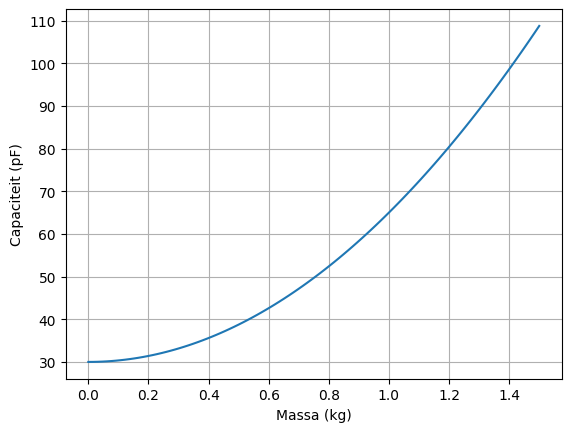

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def verband(x,a,b):
    return a * x**2+ b

x_grafiek = np.linspace(0,1.5,100)

plt.figure()
plt.plot(x_grafiek,verband(x_grafiek,35,30))
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.grid()
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 34.9 | 175 |
| gemiddelde capaciteit| 76.45 |383 |
| maximale capaciteit| 118 |580 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](metingen1.png)

## Opdracht 7: Plot de kalibratiegrafiek.

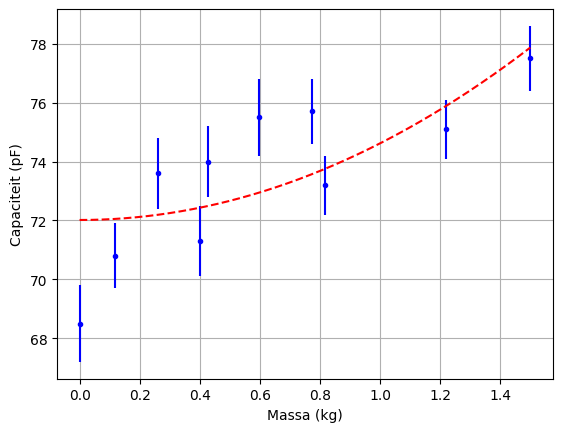

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit




gewicht = np.array([1500.9,0,402.5,815.9,1219.15,260.0,116.6,598.2,773.4,428]) * 0.001
capaciteit = np.array([77.5,68.5,71.3,73.2,75.1,73.6,70.8,75.5,75.7,74])
u_capaciteit = np.array([1.1,1.3,1.2,1.0,1.0,1.2,1.1,1.3,1.1,1.2])

popt, pcov = curve_fit(verband, gewicht ,capaciteit)
x_test = np.linspace(0.0,1.5,1000)

plt.figure()
plt.errorbar(gewicht,capaciteit,yerr=u_capaciteit,fmt='b.',label='Metingen')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.plot(x_test,verband(x_test,*popt),'r--',label='Curve Fit')
plt.grid()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* zorgen voor een veer ipv een spons, waardoor de massa minder plaatsafhankelijk is
* zorgen voor minder oppervlak bij de sensor, zodat het ook minder plaatsafhankelijk is.
* beter het materiaal van de spons bestuderen

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](image.png)

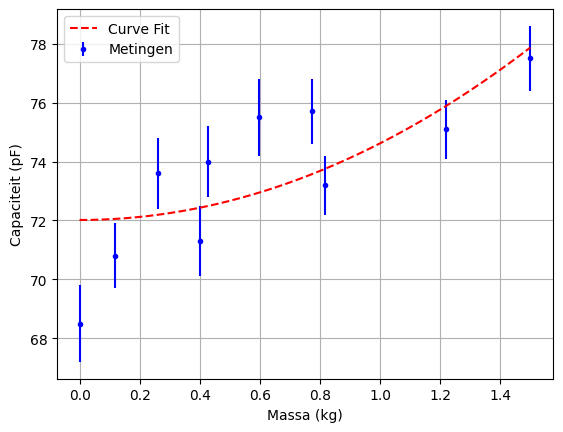

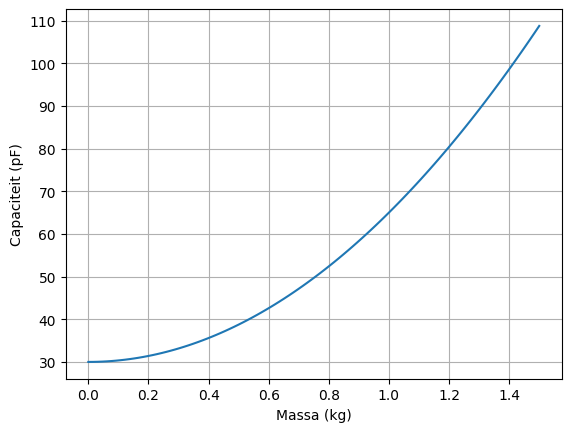

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

plt.figure()
plt.errorbar(gewicht,capaciteit,yerr=u_capaciteit,fmt='b.',label='Metingen')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.plot(x_test,verband(x_test,*popt),'r--',label='Curve Fit')
plt.legend()
plt.grid()
plt.show()

#Dit is wat we hebben

plt.figure()
plt.plot(x_grafiek,verband(x_grafiek,35,30))
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.grid()
plt.show()

#Dit was onze verwachtte grafiek

## Opdracht 10: Vul hieronder de conclusie in.

De kalibratiegrafiek was volgens onze verwachten een kwadratisch verband. Volgens onze gefitte curve bleek dit echter niet goed te passen. We hadden een probleem met de nauwkeurigheid van onze metingen. Toen we in de oscilloscoop metingen deden en onze range bepaalden, hadden we een nauwkeurige en precieze opstelling, maar in de arduino ging er iets mis, waardoor de metingen erg fluctueerden en onnauwkeurig waren. Dat had waarschijnlijk ook te maken met onze opstelling, die met kleine stukken spons tussen de condensatorplaten was.

Bovendien is de structuur van de spons een groot probleem voor de kalibratiegrafiek. Wij dachten dat er een kwadratisch verband, net als bij een veer, zou zijn op basis van metingen met de oscilloscoop, waar we massa's hadden uitgeprobeerd. Het bleek echter dat de spons totaal willekeurig reageert op druk. De Arduino meet de dikte tussen de condensatorplaten, en dus niet precies de massa die op de platen ligt. Het bleek namelijk dat de spons willekeurig dunner werd bij verschillende druk. Dit zorgt ervoor dat de kalibratiegrafiek geen mooi verband toont, en eigenlijk willekeurig op en neer gaat. Dit zorgde ervoor dat onze verwachte kalibratiegrafiek in de metingen niet goed bleek te passen. Hierdoor was de veerconstante dus ook anders dan verwacht.

Een spons springt op en neer, niet zoals een veer met een veerconstante!

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.





In [6]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
epsilon_01= 8.854e-12
epsilion_r1= 2.5
A_vlakkeplaat1= 0.010
d_vlakkeplaat1= 1e-3
C= vlakkeplaat(epsilon_01,epsilion_r1,A_vlakkeplaat1,d_vlakkeplaat1) 


print("Berekende capaciteit plaatcondensator groep 22 is",C,"pF.")



Berekende capaciteit plaatcondensator groep 22 is 2.2134999999999996e-10 pF.


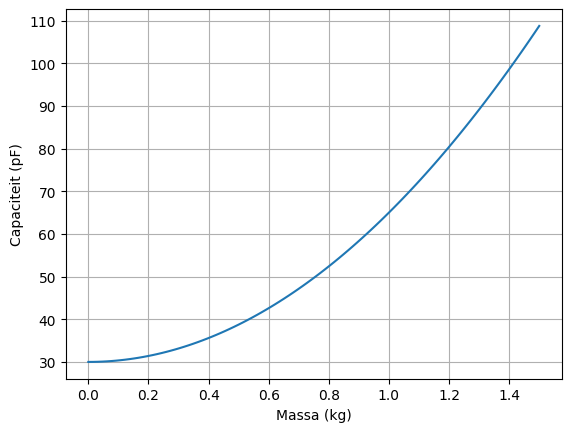

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def verband(x,a,b):
    return a * x**2+ b

x_grafiek = np.linspace(0,1.5,100)

plt.figure()
plt.plot(x_grafiek,verband(x_grafiek,35,30))
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.grid()
plt.show()

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 22| 177 pF |1,78 V | 1.34 V | 134 pF |

#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](schetsplaatcondensator.png)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

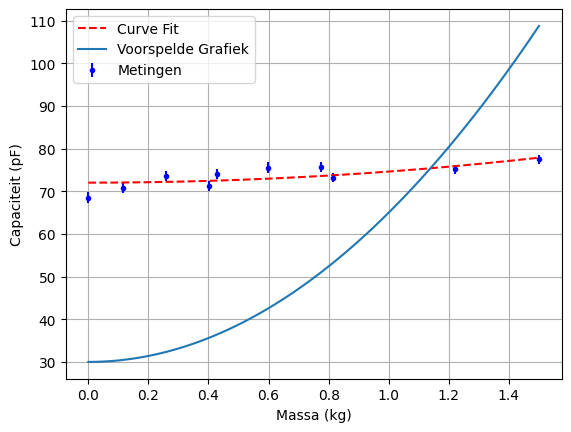

In [8]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

plt.figure()
plt.errorbar(gewicht,capaciteit,yerr=u_capaciteit,fmt='b.',label='Metingen')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.plot(x_test,verband(x_test,*popt),'r--',label='Curve Fit')
plt.plot(x_grafiek,verband(x_grafiek,35,30),label='Voorspelde Grafiek')
plt.legend()
plt.grid()
plt.show()



We hadden met de formule voorspeld dat de range zou zijn tussen 30 en 118 pF met de oscilloscoop, en dat deze een verband als een veer zou hebben, maar dat bleek niet zo te zijn. In de Arduino ging de range ineens van 68 naar 78 pF, wat totaal niet overeenkomt met de verwachting en wat ervoor zorgt dat het niet in de buurt komt. Bovendien bleek het kwadratische verband ook niet echt te passen, en eigenlijk geen enkel verband door de onvoorspelbaarheid van de spons. Daarom komt de kalibratiegrafiek niet goed overeen met ons verband.
De onzekerheden waren laag ingeschat, in het experiment hadden ze ook 2 keer zo groot kunnen zijn. Dat kwam ook omdat het moeilijk was om met Arduino, doordat er steeds veel metingen in een keer komen, het moeilijk was om de onzekerheid goed te bepalen. Bovendien veranderde de output ook als er een draadje werd aangeraakt. Hierdoor is de onzekerheid kleiner dan de bedoeling was.